In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [5]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast

shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_store1.csv", index_col=0)
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates_store1.csv", index_col=0)

df = shop_sales.merge(shop_dates, on="date_id", how="left")


num_exog_cols = [
    'month',
    'wday',
    'year',
    'CASHBACK'
]

cat_exog_cols = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]

for col in cat_exog_cols:
    df[col] = (~df[col].isna()).astype(np.int32)    

exog_cols = num_exog_cols + cat_exog_cols

df = df[['item_id', 'date', 'cnt'] + exog_cols]


holiday_cols = [
    'event_name_1',
    'event_name_2',
    'CASHBACK'
]

In [6]:
horizon = 30
last_k_days = 62
train = df.iloc[:-horizon]

multi_fc = MultiItemForecaster(model_name="ml")


# обучаем модель на train
multi_fc.fit(train,exog_cols=exog_cols, lags=[7**k for k in range(4)], trend_window=7)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 234
[LightGBM] [Info] Number of data points in the train set: 1819, number of used features: 10
[LightGBM] [Info] Start training from score 0.005183
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 1819, number of used features: 10
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightG

In [4]:
df.item_id.unique().tolist()

['STORE_1_046',
 'STORE_1_033',
 'STORE_1_043',
 'STORE_1_090',
 'STORE_1_099',
 'STORE_1_131',
 'STORE_1_252',
 'STORE_1_295',
 'STORE_1_304',
 'STORE_1_491',
 'STORE_1_542',
 'STORE_1_555',
 'STORE_1_586',
 'STORE_1_587',
 'STORE_1_714']

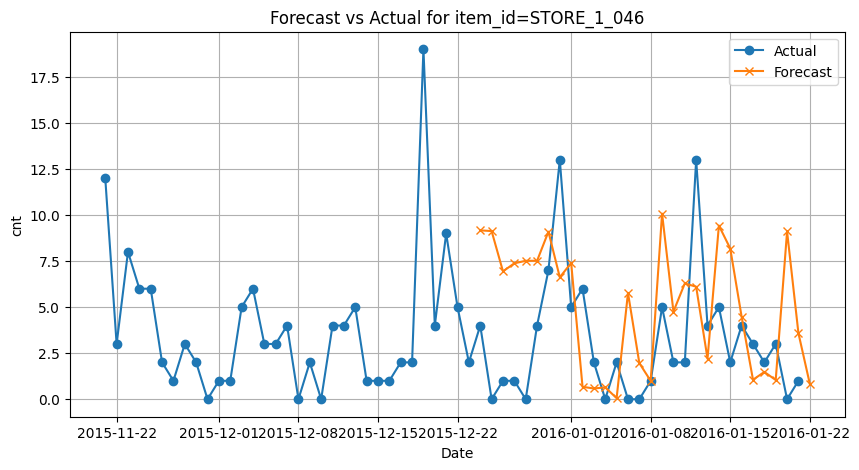

In [10]:
forecasts = multi_fc.predict(horizon, df, exog_cols=exog_cols)

plot_forecast(
    df,
    forecasts, 
    item_id='STORE_1_046', 
    horizon=horizon,
    last_k_days=last_k_days,
    # holiday_cols=holiday_cols
    )


In [10]:
metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon, exog_cols=exog_cols)
pd.DataFrame(metrics_agg.items()).T
#add_cat


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 227
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 10
[LightGBM] [Info] Start training from score 0.006468
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 172
[LightGBM] [Info] Number of data points in the train set: 1789, number of used features: 10
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001711 seconds.
Y

,0,1,2,3,4,5
0,SMAPE,WAPE,RMSE,MASE,MAE,MAPE
1,0.913331,123324425.281028,11.578533,1.592815,9.112363,931545167.54382
